# BEE 4750 Homework 1: Introduction to Using Julia

**Name**: Evan Tyler Wu

**ID**: 5839048

> **Due Date**
>
> Thursday, 9/11/25, 9:00pm

## Overview

### Instructions

-   Problem 1 consist of a series of code snippets for you to interpret
    and debug. You will be asked to identify relevant error(s) and fix
    the code.
-   Problem 2 asks you to write code to implement several simple
    functions using more general programming and some which are unique
    to Julia (which might mean that you need to look at the
    documentation or use Julia’s help function, which is accessed with
    `?`, e.g. `?sum` for help with the `sum()` function) or to analyze
    Julia syntax.
-   Problem 3 asks you to convert a verbal description of a wastewater
    treatment system into a Julia function, and then to use that
    function to explore the impact of different wastewater allocation
    strategies.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [2]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `c:\Users\evant\OneDrive\Documents\GitHub\bee4750-hw1-evo`


Standard Julia practice is to load all needed packages at the top of a
file. If you need to load any additional packages in any assignments
beyond those which are loaded by default, feel free to add a `using`
statement, though [you may need to install the
package](https://viveks.me/environmental-systems-analysis/tutorials/julia-basics.html#package-management).

In [3]:
using Random
using Plots
using GraphRecipes
using LaTeXStrings
using Distributions

In [4]:
# this sets a random seed, which ensures reproducibility of random number generation. You should always set a seed when working with random numbers.
Random.seed!(1)

TaskLocalRNG()

## Problems (Total: 30 Points)

### Problem 1 (12 points)

The following subproblems all involve code snippets that require
debugging. You are encouraged to use online resources (*e.g.* Julia
documentation and forums, Stack Overflow, Reddit, etc) to help find
diagnose error messages and find solutions, but make sure that you
clearly document which resources you used and how you used them.

#### Problem 1.1

You’ve been tasked with writing code to identify the minimum value in an
array. You cannot use a predefined function. Your colleague suggested
the function below, but it does not return the minimum value.

In [5]:
function minimum(array)
    # initialize the minimum value counter
    min_value = array[1]
    # update minimum values
    for i in 1:length(array)
        if array[i] < min_value
            min_value = array[i]
        end
    end
    # return found minimum
    return min_value
end

array_values = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
@show minimum(array_values);

minimum(array_values) = 78


What is the logical flaw in the code? Fix it and show that your fixed
code solves the problem.

The logical flaw in the code is that it attempts to compare the values of the array with a minimum value of 0. Since all the numbers in the array are positive, the for loop will always fail and output a minimum value of 0. 

To amend this, the minimum value in line 3 should be changed from 0 to array[1]. This changes the function to compare starting from the 1st value of the array instead of 0, and the actual minimum value of 78 can be attained.

#### Problem 1.2

Your team is trying to compute the average grade for your class, but the
following code produces an `UndefVarError`.

In [6]:
# enter student grade vector
student_grades = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
# compute class average
function class_average(grades)
  average_grade = sum(student_grades) / length(student_grades)
  return average_grade
end

@show class_average(student_grades);

class_average(student_grades) = 94.4


What does this `UndefVarError` mean? Why does this code produce one? Fix
the error and solve the problem.
UndefVarError happens when a variable in the code is not properly defined. 
This code produces an UndefVarError because it attempts to show average_grade. Although it is defined in the function class_average, this function is never used. Therefore, the code attempts to show a variable that does not exist. 

This can be fixed by rewriting line 9 to @show class_average(student_grades). This lets the class_average function run and displays the output as intended. Line 5 is also modified to replace mean(student_grades) into sum(student_grades) / length(student_grades). 
Source: https://www.jlhub.com/julia/manual/en/function/UndefVarError  

#### Problem 1.3

Your team wants to know the expected payout of an old Italian dice game
called *passadieci* (which was analyzed by Galileo as one of the first
examples of a rigorous study of probability). The goal of passadieci is
to get at least an 11 from rolling three fair, six-sided dice. Your
strategy is to compute the average wins from 1,000 trials, but the code
you’ve written below produces a `MethodError`.

In [7]:
# function to simulate a passadieci roll: 3 6-sided dice
function passadieci()
    # this rand() call samples 3 values from the vector [1, 6]
    roll = rand(1:6, 3) 
    return roll
end
# set number of trials and initialize outcome vector
n_trials = 1_000
outcomes = zeros(n_trials)
# simulate number of passadieci rolls and count wins
for i = 1:n_trials
    outcomes[i] = (sum(passadieci()) > 11)
end
win_prob = sum(outcomes) / n_trials # compute average number of wins
@show win_prob;

win_prob = 0.382


What does this `MethodError` mean? Why does this code produce one? Fix
the error and solve the problem.
This MethodError refers to when a function receives inputs that either doesn’t match the suitable type or number of variables. 
The code produces MethodError because the for loop starting from line 11 establishes the outcomes output as an array, however the variable outcomes is established in line 9 is established as a single number with zero(n_trials). This creates a contradiction as an array cannot fit into a variable with only 1 number.

The code can be fixed in line 9 by replacing zero(n_trials) to zeros(n_trials). The difference is the zero() function only outputs a single 0, whereas zeros() function creates an array of 0s. This is significant as the outcomes variable needs to be an array to store the different cases where the die rolled successfully.
Source: https://www.jlhub.com/julia/manual/en/function/MethodError 
#### Problem 1.4

You’re interested in writing some code to remove the mean of a vector
from all of its components. You’ve written the following code and tried
to test it on a random vector, but your code returns a `MethodError`.

In [8]:
# function to remove mean from a vector
function remove_mean(vect)
    # fucntion to compute the mean
    function compute_mean(vect)
        element_sum = 0 # initialize sum
        # compute mean and return
        for v in vect
            element_sum += v
        end
        return element_sum / length(vect)
    end

    m = compute_mean(vect) # compute mean
    # return demeaned vector
    return vect .- m
end

random_vect = rand(1_000)
@show remove_mean(random_vect)

remove_mean(random_vect) = [0.41919142411294885, -0.04477120169153992, -0.15987063495003362, -0.3165390583665356, -0.04345183269168251, 0.4600428661267356, -0.4814808404373695, 0.05265958609672772, -0.019033198532207418, 0.11752715148103854, -0.2530763598508532, -0.3987461186978969, -0.4051668577883766, -0.14537708102382318, -0.021518846454485097, 0.2393846697392613, -0.13828803455335292, 0.28932439329980286, -0.44190436643288566, -0.41462031768210295, -0.1481768399620188, -0.4467685839176895, 0.16354702958537648, -0.324893449617489, -0.22436376824831783, 0.18691945805247367, -0.2843753736563317, 0.30832500598057266, 0.2757047181327851, 0.44059511305789445, 0.12832592230812423, 0.1935791502153814, 0.2896691235161918, -0.05389047441266104, 0.1218772930619838, -0.24482626621372394, 0.22316484875624798, 0.4597763846856109, -0.33758006386107464, 0.19126011359930628, -0.3305504301513418, -0.20836963537351572, 0.4435549655840101, 0.14379124696474477, 0.3902589386802747, -0.2551400209756388, 

1000-element Vector{Float64}:
  0.41919142411294885
 -0.04477120169153992
 -0.15987063495003362
 -0.3165390583665356
 -0.04345183269168251
  0.4600428661267356
 -0.4814808404373695
  0.05265958609672772
 -0.019033198532207418
  0.11752715148103854
  ⋮
  0.1701029484937252
 -0.45332724205642416
 -0.4743008238822817
 -0.4129715382326393
  0.23830378602543056
  0.06271140871181402
  0.11506229654060751
 -0.1638906511382653
 -0.0897920909169232

What does this `MethodError` mean? Why does this code produce one? Fix
the error and solve the problem.

This MethodError refers to the situation when a scalar is attempted to be taken out of a vector improperly. 
This error happens in this code at line 15 because of the – sign used. The – operator is only applicable in operations with multiple vectors. This does not work in this scenario as only a single data point 

The code can be fixed by replacing the – operator with a .- operator instead. The .- operator is used to enable element-wise operations (individual data points) within a vector.

Source: https://www.jlhub.com/julia/manual/en/function/MethodError 


### Problem 2 (18 points)

Cheap Plastic Products, Inc. is operating a plant that produces
$100 \text{m}^3\text{/day}$ of wastewater that is discharged into
Pristine Brook. The wastewater contains $1 \text{kg/m}^3$ of YUK, a
toxic substance. The US Environmental Protection Agency has imposed an
effluent standard on the plant prohibiting discharge of more than
$20 \text{kg/day}$ of YUK into Pristine Brook.

Cheap Plastic Products has analyzed two methods for reducing its
discharges of YUK. Method 1 is land disposal, which costs $X_1^2/20$
dollars per day, where $X_1$ is the amount of wastewater disposed of on
the land ($\text{m}^3\text{/day}$). With this method, 20% of the YUK
applied to the land will eventually drain into the stream (*i.e.*, 80%
of the YUK is removed by the soil).

Method 2 is a chemical treatment procedure which costs \$1.50 per
$\text{m}^3$ of wastewater treated. The chemical treatment has an
efficiency of $e= 1 - 0.005X_2$, where $X_2$ is the quantity of
wastewater ($\text{m}^3\text{/day}$) treated. For example, if
$X_2 = 50 \text{m}^3\text{/day}$, then $e = 1 - 0.005(50) = 0.75$, so
that 75% of the YUK is removed.

Cheap Plastic Products is wondering how to allocate their wastewater
between these three disposal and treatment methods (land disposal,
chemical treatment, and direct disposal) to meet the effluent standard
while keeping costs manageable.

The flow of wastewater through this treatment system is shown in
<a href="#fig-wastewater" class="quarto-xref">Figure 1</a>. Modify the
edge labels (by editing the `edge_labels` dictionary in the code
producing <a href="#fig-wastewater" class="quarto-xref">Figure 1</a>) to
show how the wastewater allocations result in the final YUK discharge
into Pristine Brook. For the `edge_label` dictionary, the tuple $(i, j)$
corresponds to the arrow going from node $i$ to node $j$. The syntax for
any entry is `(i, j) => "label text"`, and the label text can include
mathematical notation if the string is prefaced with an `L`, as in
`L"x_1"` will produce $x_1$.

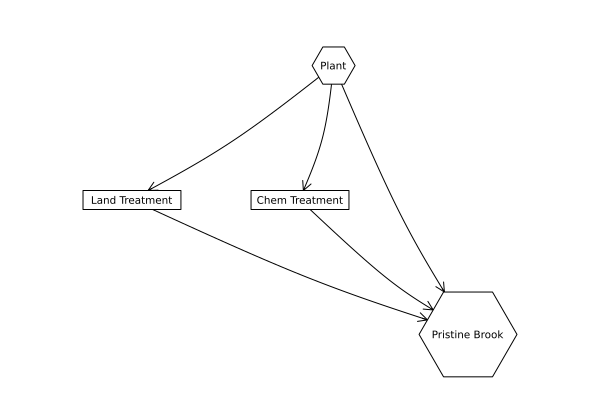

In [9]:
A = [0 1 1 1;
    0 0 0 1;
    0 0 0 1;
    0 0 0 0]

names = ["Plant", "Land Treatment", "Chem Treatment", "Pristine Brook"]
# modify this dictionary to add labels
edge_labels = Dict((1, 2) => "", (1,3) => "", (1, 4) => "",(2, 4) => "",(3, 4) => "")
shapes=[:hexagon, :rect, :rect, :hexagon]
xpos = [0, -1.5, -0.25, 1]
ypos = [1, 0, 0, -1]

p = graphplot(A, names=names,edgelabel=edge_labels, markersize=0.15, markershapes=shapes, markercolor=:white, x=xpos, y=ypos)
display(p)

#### Problem 2.1

Formulate a mathematical model for the treatment cost and the amount of
YUK that will be discharged into Pristine Brook based on the wastewater
allocations. This is best done with some equations and supporting text
explaining the derivation. Make sure you include, as additional
equations in the model, any needed constraints on relevant values. You
can find some basics on writing mathematical equations using the LaTeX
typesetting syntax
[here](https://viveks.me/environmental-systems-analysis/tutorials/latex-notebook.qmd),
and a cheatsheet with LaTeX commands can be found on the course
website’s [Resources
page](https://viveks.me/environmental-systems-analysis/resources/markdown.qmd).

A mathematical model for the treatment cost and YUK discharge can be found by establishing a system that assesses YUK inflow from the plant and YUK outflow to Pristine Brook. YUK discharge is assessed with a material balance equation, while treatment cost can be evaluated by sum of the costs of Method 1 and Method 2. The general material balance equation is listed below:

$ Inlet - Outlet - Consumption + Generation = Accumulation$

First, all the known quantities are outlined below: 

Wastewater inlet = $100 \frac{m^3}{day}$ 

YUK in wastewater = $1 \frac{kg}{m^3}$

YUK discharge limit = $20 \frac{kg}{day}$

Method 1 cost: $\frac{X_1^2}{20} \frac{dollars}{day}$

Method 1 YUK generation: $0.2X_1$

Method 2 cost: $\frac{1.5}{m^3}$

Method 2 efficiency: $e = 1 - 0.005X_2$

With the provided information, the amount of YUK incoming, consumed, and generated can be deduced:  

Incoming YUK from plant: $100 \frac{m^3}{day}\times 1\frac{kg}{m^3} = 100 \frac{kg}{day}$

Method 1 YUK generation: $0.2X_1$

Method 2 YUK generation: $\left(1-e\right)X_2$ = $\left(1-\left(1-0.005X_2\right)\right)X_2 = 0.005X_2^2$

Remaining YUK after Method 1 and 2: $ 100 - X_1 - X_2$

With these variables, the material balance equation can be set up. Few assumptions must be made to make the equation solvable with the provided parameter:
- There is no accumulation / Accumulation = 0
- $X_1 + X_2 \leq 100$ (Cannot have more material out than in)

Going back and deriving the material balance equation:

$ Inlet - Outlet - Consumption + Generation = Accumulation$

Consumption = $-X_1 - X_2$, Generation = $+ 0.2X_1 + 0.005X_2^2$

$ Inlet - M1used - M2used - Outlet + M1 left + M2 left = 0$

$ 100 -X_1 -X_2  + 0.2X_1 + 0.005X_2^2 = Outlet$

After simplification, the general material balance equation would be:

$ 100 - 0.8X_1 -X_2 + 0.005X_2^2 = Outlet$ in $\frac{kg}{day}$

- When considering the constraint of the outlet (Cannot be larger than $20\frac{kg}{day}$):

$ 100 - 0.8X_1 -X_2 + 0.005X_2^2 = 20$

$ 80 - 0.8X_1 - X_2 + 0.005X_2^2 = 0$

$ 80 \ge 0.8X_1 + X_2 - 0.005X_2^2 $

For the total financial cost:

Method 1 cost + Method 2 cost = Total

$\frac{X_1^2}{20} + 1.5X_2 =$ Total in $\frac{dollars}{day}$

#### Problem 2.2

Implement your systems model as a Julia function which computes the
resulting YUK discharge and cost for a particular treatment plan. You
can return multiple values from a function with a
[tuple](https://docs.julialang.org/en/v1/manual/functions/#Tuples-1), as
in:

In [10]:
function multiple_return_values(x, y)
    return (x+y, x*y)
end

a, b = multiple_return_values(2, 5)
@show a;
@show b;

a = 7
b = 10


To evalute the function over vectors of inputs, you can *broadcast* the
function by adding a decimal `.` before the function arguments and
accessing the resulting values by writing a *comprehension* to loop over
the individual outputs in the vector:

M = [82.5, 70.125, 50.5, 36.0, 22.5, 26.0, 20.0, 18.5, 18.0, 18.5, 20.0, 50.0]
C = [20.0, 42.5, 90.0, 140.0, 200.0, 170.0, 240.0, 290.0, 350.0, 420.0, 500.0, 150.0]


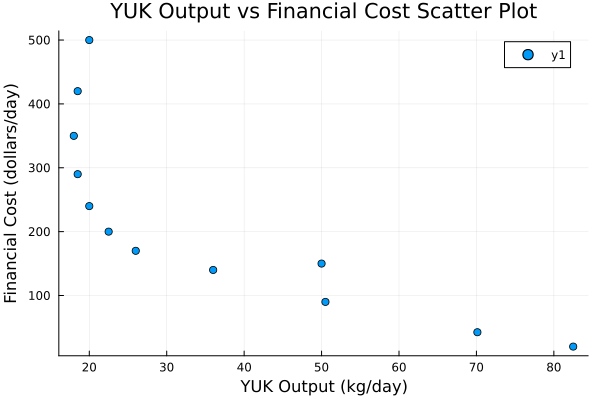

In [11]:
function multiple_return_values(x, y)
    # Material balance equation
    # 100 .- 0.8x .- y + 0.005.*y.^2

    # Finance cost equation
    # C1 = x.^2/20
    # C2 = 1.5.*y
    # C = C1 + C2
    return (100 .- 0.8x .- y + 0.005.*y.^2, x.^2/20 .+ 1.5.*y) # Return YUK output and financial cost
end

x = [10, 20, 30, 40, 50, 40, 60, 70, 80, 90, 100, 0] # X1 values
y = [10, 15, 30, 40, 50, 60, 40, 30, 20, 10, 0, 100]  # X2 values

output = multiple_return_values.(x, y)
M = [out[1] for out in output] # Display YUK output in kg/day
C = [out[2] for out in output] # Display financial cost
@show M;
@show C;
plot(M, C, seriestype=:scatter, xlabel="YUK Output (kg/day)", ylabel="Financial Cost (dollars/day)", title="YUK Output vs Financial Cost Scatter Plot")

Make sure you comment your code appropriately to make it clear what is
going on and why.


The function multiple_return_values(x,y) is coded such that it returns 2 separate values based on YUK output and financial cost for X and Y respectively. Afterwards, we create 2 separate arrays X and Y based on the amount of waste used in Method 1 and Method 2. In order to fit with the constraints of the above equation, the sum of X and Y in one column cannot be greater than 100. 

The YUK output and financial cost are displayed by the multiple_return_values function based on the x and y arrays. Afterwards, YUK output vs financial cost is graphed as a scatter plot as illustrated above. A scatter plot was chosen to best identify the nature of the relationship between YUK and financial cost. From the scatter plot, a nonlinear relationship could be observed where YUK output decreases as financial cost increases from 0 dollars to 350 dollars. However, from 350 dollars onwards the YUK output increases slightly. 


#### Problem 2.3

Use your function to experiment with 1,000 different combinations of
wastewater discharge and treatment. You can do this with either a grid
search or by sampling from a [Dirichlet
distribution](https://en.wikipedia.org/wiki/Dirichlet_distribution) (a
$\text{Dirichlet}(1, n)$ distribution will generate uniformly-weighted
$n$-dimensional vectors whose components add up to 1; see the
[`Distributions.jl`
documentation](https://juliastats.org/Distributions.jl/stable/starting/)
for how to sample from probability distributions in Julia). Plot the
results of these experiments. Do any satisfy the YUK effluent standard
(plot this as well as a dashed red line). What was the cost of solutions
satisfying the standard? What can you say about the tradeoff between
treatment cost and YUK discharge? You don’t have to find an “optimal”
solution to this problem, but what do you think would be needed to find
a better solution?

Problem 2.3:

length(x_samples) = 1000
length(y_samples) = 1000
minimum(M) = 18.000008533205808
minimum(New_C) = 240.2383256877098


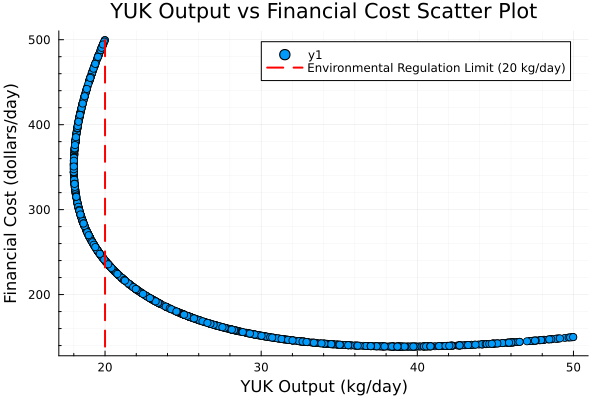

In [83]:
function multiple_return_values(x, y)
    # Material balance equation
    # 100 .- 0.8x .- y + 0.005.*y.^2

    # Finance cost equation
    # C1 = x.^2/20
    # C2 = 1.5.*y
    # C = C1 + C2
    return (100 .- 0.8x .- y + 0.005.*y.^2, x.^2/20 .+ 1.5.*y) # Return YUK output and financial cost
end

distribution = Dirichlet(2,1); 
samples = rand(distribution, 1000) # Generate 1000 samples from Dirichlet distribution
x_samples = 100*samples[1, :];
y_samples = 100*samples[2, :];
@show length(x_samples) # Check length of samples
@show length(y_samples) # Check length of samples

output = multiple_return_values.(x_samples, y_samples)
M = [out[1] for out in output] # Display YUK output in kg/day
C = [out[2] for out in output] # Display financial cost
@show minimum(M) # Check minimum of YUK output
findmin = findall(x -> x <= 20, M) # Find all instances where YUK output is less than or equal to 20 kg/day
New_M = M[findmin] # New M values that meet the regulation
New_C = C[findmin] # Corresponding financial costs
@show minimum(New_C) # Check minimum of financial cost that meets regulation

plot(M, C, seriestype=:scatter, xlabel="YUK Output (kg/day)", ylabel="Financial Cost (dollars/day)", title="YUK Output vs Financial Cost Scatter Plot", minorgrid=true)
red_line_y = [minimum(C), maximum(C)]
plot!( [20,20], red_line_y, line=:dash, linecolor=:red, linewidth=2, label="Environmental Regulation Limit (20 kg/day)")

In Problem 2.3, we keep the multiple_functions_value function and the scatter plot for the data points the same. However, we modify the input data used with a Dirichlet distribution to create a [2x1000] array where each column of randomized X1 and X2 values sum into 1. A Dirichlet distribution is used as based on the preliminary data points in Problem 2.2, it is recommended to treat all incoming YUK with a composition of Method 1 and 2. However, the optimal combination of wastewaster going into M1 and M2 are not known. Therefore, random combinations of M1 and M2 are tried to model a relationship between YUK outpost and cost. These values are then multiplied by 100 to match the total incoming YUK from the plant. To confirm that 1000 different combinations are used, the length of x_samples and y_samples are displayed. To observe which combinations are valid, a red dashed line is placed at x = 20. The minimum values of the YUK output and financial cost that satisfy the standard are also displayed.

On this plot, while a majority of combinations exceed the maximum possible YUK output, there are a list of combinations that satisfies the standard. The range of financial costs where the standard is met is from approximately 220 to 500 dollars per day. Based on the trend of this plot, the tradeoff between treatment cost and YUK output is that increasing treatment cost results in diminishing returns of YUK output. Although the current results suggest a reasonable solution, a better solution could be found by finding the combinations of M1 and M2 values that satisfy the standard and sampling 1000 combinations within that range.

Source for findall function: https://docs.julialang.org/en/v1/base/arrays/#Base.findall-Tuple%7BFunction,%20Any%7D 

#### Problem 2.4

Find the strategies which minimize cost and YUK discharge (these will be
different strategies) analytically and find the values of the objective
metrics. Plot these values in the plot that you created for Problem 2.3.
How do their values compare to the spread of values that you found in
that problem? Would you select either of them (explain why or why not)?

## References

List any external references consulted, including classmates.